## Modules

In [44]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [45]:
import torch
import numpy as np
import pandas as pd
import cv2
import torch.nn as nn
import torchvision
from torchvision import models

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Config

In [47]:
# ==========================================
# Configuration
# ==========================================

import torch

# Reproducibility
RANDOM_SEED = 42

# Image settings
IMAGE_SIZE = 224

# DataLoader settings
BATCH_SIZE = 64
NUM_WORKERS = 0
PREFETCH_FACTOR = 2

# Training settings
FROZEN_EPOCHS = 5
FINETUNE_EPOCHS = 12

# Learning rates
FROZEN_LR = 1e-3
FINETUNE_LR = 0.0003

# Optimizer
WEIGHT_DECAY = 1e-4

# Regularization
DROPOUT = 0.23

# Early stopping
EARLY_STOPPING_PATIENCE = 5

# Learning-rate scheduler
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_FACTOR = 0.22

# Speed optimizations
USE_AMP = True
USE_TORCH_COMPILE = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [48]:
# ==========================================
# GPU optimizations
# ==========================================

if torch.cuda.is_available():

    # Allow TF32 for faster matrix multiplication
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Automatically select the fastest convolution algorithms
    torch.backends.cudnn.benchmark = True

    print("CUDA optimizations enabled.")

CUDA optimizations enabled.


## Training on 2019 dataset initially

### creating dataframe

In [49]:
df=pd.read_csv("ISIC_2019_Training_GroundTruth.csv")
print(df.head())
print(df.columns)
print(df.shape)

          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
Index(['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK'], dtype='object')
(25331, 10)


In [50]:
df = df[["image", "MEL", "BCC", "SCC"]]

# Display the first 5 rows
print(df.head())

# Display the number of rows and columns
print("Shape:", df.shape)

          image  MEL  BCC  SCC
0  ISIC_0000000  0.0  0.0  0.0
1  ISIC_0000001  0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0
3  ISIC_0000003  0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0
Shape: (25331, 4)


In [51]:
# Create the binary label
df["label"] = (
    (df["MEL"] == 1) |
    (df["BCC"] == 1) |
    (df["SCC"] == 1)
).astype(int)

# Check the result
print(df.head())

          image  MEL  BCC  SCC  label
0  ISIC_0000000  0.0  0.0  0.0      0
1  ISIC_0000001  0.0  0.0  0.0      0
2  ISIC_0000002  1.0  0.0  0.0      1
3  ISIC_0000003  0.0  0.0  0.0      0
4  ISIC_0000004  1.0  0.0  0.0      1


In [52]:
df = df[["image", "label"]]

print(df.head())
print(df["label"].value_counts())

          image  label
0  ISIC_0000000      0
1  ISIC_0000001      0
2  ISIC_0000002      1
3  ISIC_0000003      0
4  ISIC_0000004      1
label
0    16858
1     8473
Name: count, dtype: int64


### verifying images

In [53]:
from pathlib import Path

# Folder containing the ISIC .jpg images
image_dir = Path("ISIC_2019_Training_Input/ISIC_2019_Training_Input")

# Create the full path for every image
df["image_path"] = df["image"].apply(
    lambda x: image_dir / f"{x}.jpg"
)

# Check that the first image exists
print("First image path:", df["image_path"].iloc[0])
print("Image exists:", df["image_path"].iloc[0].exists())

# Check how many image files actually exist
print("Total images in CSV:", len(df))
print("Images found:", df["image_path"].apply(lambda x: x.exists()).sum())
print("Images missing:", (~df["image_path"].apply(lambda x: x.exists())).sum())

First image path: ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000000.jpg
Image exists: True
Total images in CSV: 25331
Images found: 25331
Images missing: 0


### Train-Test-Val Split

In [54]:
from sklearn.model_selection import train_test_split
import pandas as pd

# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Second split: 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# Function to calculate class distribution
def get_distribution(data):
    total = len(data)
    benign = (data["label"] == 0).sum()
    malignant = (data["label"] == 1).sum()

    return {
        "Total": total,
        "Benign": benign,
        "Malignant": malignant,
        "Benign %": round((benign / total) * 100, 2),
        "Malignant %": round((malignant / total) * 100, 2)
    }


# Create distribution table
distribution = pd.DataFrame({
    "Train": get_distribution(train_df),
    "Validation": get_distribution(val_df),
    "Test": get_distribution(test_df)
}).T

print(distribution)

              Total   Benign  Malignant  Benign %  Malignant %
Train       17731.0  11800.0     5931.0     66.55        33.45
Validation   3800.0   2529.0     1271.0     66.55        33.45
Test         3800.0   2529.0     1271.0     66.55        33.45


In [55]:
# ==========================================
# Image transformations
# ==========================================

from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

## Pytorch Configs...

### Defining Datasets class and creating dataset objects

In [56]:
from torch.utils.data import Dataset
from PIL import Image


class ISICDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # Get the image path and label for this row
        image_path = self.dataframe.iloc[index]["image_path"]
        label = self.dataframe.iloc[index]["label"]

        # Open the image and convert it to RGB
        image = Image.open(image_path).convert("RGB")

        # Apply the specified transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to a PyTorch tensor
        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [57]:
train_dataset = ISICDataset(
    train_df,
    transform=train_transform
)

val_dataset = ISICDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = ISICDataset(
    test_df,
    transform=val_test_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 17731
Validation dataset: 3800
Test dataset: 3800


### Handling imbalance in training data

Rather than deleting benign images, we'll use WeightedRandomSampler. This means malignant images will be selected more frequently during training.

In [58]:
from torch.utils.data import DataLoader, WeightedRandomSampler

# Count the number of samples in each class
class_counts = train_df["label"].value_counts().sort_index()

print("Class counts:")
print("Benign:", class_counts[0])
print("Malignant:", class_counts[1])


# Calculate a weight for each class
class_weights = 1.0 / torch.tensor(
    class_counts.values,
    dtype=torch.float
)

print("\nClass weights:")
print("Benign:", class_weights[0].item())
print("Malignant:", class_weights[1].item())


# Give every training image the weight of its class
sample_weights = train_df["label"].map(
    lambda label: class_weights[label].item()
).values

sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.float32
)


# Create the sampler
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True  #basically means images can be shown mulitple times during an epoch, with random transformations
)





Class counts:
Benign: 11800
Malignant: 5931

Class weights:
Benign: 8.4745763160754e-05
Malignant: 0.00016860563482623547


In [59]:

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
)


print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 278
Validation batches: 60
Test batches: 60


## Buildling model

### ResNet50 Two-Stage Fine-Tuning Strategy

This document outlines the **two-stage fine-tuning workflow** for training a transfer-learning model using a pre-trained **ResNet50** backbone. This strategy prevents gradient shock and catastrophic forgetting while adapting high-level features to the target domain.

---

### 📊 Overview Flowchart

```text
               PRETRAINED RESNET50
                        │
                        ▼
             ┌──────────────────┐
             │     STAGE 1      │
             │                  │
             │  All ResNet  ❄️  │
             │  FC Head     🔥  │
             │                  │
             │  LR = 1e-3       │
             │  Max 10 Epochs   │
             └────────┬─────────┘
                      │
                      ▼
             Best Stage 1 Model
                      │
                      ▼
             ┌──────────────────┐
             │     STAGE 2      │
             │                  │
             │  layer4      🔥  │
             │  FC Head     🔥  │
             │  Others      ❄️  │
             │                  │
             │  LR = 1e-5       │
             │  Max 15 Epochs   │
             └────────┬─────────┘
                      │
                      ▼
              Best Final Model

In [60]:
# ==========================================
# ResNet50
# ==========================================

from torchvision import models
import torch.nn as nn


model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)


# Freeze everything
for param in model.parameters():
    param.requires_grad = False


# Replace ImageNet classifier
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(DROPOUT),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(DROPOUT),

    nn.Linear(128, 1)
)

# Move model to GPU
model = model.to(DEVICE)

# Use channels-last memory format
model = model.to(memory_format=torch.channels_last)


print(model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.23, inplace=False)
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.23, inplace=False)
  (6): Linear(in_features=128, out_features=1, bias=True)
)


### using torch.compile

In [61]:
USE_TORCH_COMPILE = False

In [62]:
# ==========================================
# Optional torch.compile
# ==========================================

if USE_TORCH_COMPILE:

    model = torch.compile(
        model,
        mode="max-autotune"
    )

    print("torch.compile enabled.")

### Loss, optimizer and AMP

In [63]:
# ==========================================
# Stage 1 training setup
# ==========================================

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()


optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=FROZEN_LR,
    weight_decay=WEIGHT_DECAY
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE
)


# Automatic Mixed Precision
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP and torch.cuda.is_available()
)


print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", FROZEN_LR)
print("AMP enabled:", scaler.is_enabled())

Optimizer: AdamW
Learning rate: 0.001
AMP enabled: True


In [64]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 24622913
Trainable parameters: 1114881


## Training the model

### defining training and validation func

In [65]:
# ==========================================
# Training function
# ==========================================

from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_probs = []

    # Progress bar
    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        # Move data to GPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Channels-last memory format
        images = images.contiguous(
            memory_format=torch.channels_last
        )

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP and torch.cuda.is_available()
        ):

            outputs = model(
                images
            ).squeeze(1)

            loss = criterion(
                outputs,
                labels
            )

        # Backpropagation
        scaler.scale(loss).backward()

        # Update weights
        scaler.step(optimizer)

        scaler.update()

        # Store loss
        running_loss += (
            loss.item() * images.size(0)
        )

        # Convert logits to probabilities
        probabilities = torch.sigmoid(
            outputs
        )

        all_labels.append(
            labels.detach().cpu()
        )

        all_probs.append(
            probabilities.detach().cpu()
        )

        # Show current batch loss
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    # Average loss
    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    # Calculate AUC
    all_labels = torch.cat(
        all_labels
    ).numpy()

    all_probs = torch.cat(
        all_probs
    ).numpy()

    epoch_auc = roc_auc_score(
        all_labels,
        all_probs
    )

    return epoch_loss, epoch_auc

In [66]:
# ==========================================
# Validation function
# ==========================================

def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []

    # No gradients during validation
    with torch.inference_mode():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            images = images.contiguous(
                memory_format=torch.channels_last
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=USE_AMP and torch.cuda.is_available()
            ):

                outputs = model(
                    images
                ).squeeze(1)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += (
                loss.item() * images.size(0)
            )

            probabilities = torch.sigmoid(
                outputs
            )

            all_labels.append(
                labels.cpu()
            )

            all_probs.append(
                probabilities.cpu()
            )

            # Show current validation loss
            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    # Average validation loss
    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    # Calculate AUC
    all_labels = torch.cat(
        all_labels
    ).numpy()

    all_probs = torch.cat(
        all_probs
    ).numpy()

    epoch_auc = roc_auc_score(
        all_labels,
        all_probs
    )

    return epoch_loss, epoch_auc

In [67]:
# ==========================================
# Checkpoint folder
# ==========================================

from pathlib import Path

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Checkpoints will be saved in:", CHECKPOINT_DIR)

Checkpoints will be saved in: checkpoints


In [68]:
import time

stage1_start_time = time.time()

### testing

In [69]:
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Batch size:", images.shape[0])

Batch shape: torch.Size([64, 3, 224, 224])
Batch size: 64


In [70]:
# ==========================================
# Test batch size 64 on GPU
# ==========================================

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

images = images.contiguous(
    memory_format=torch.channels_last
)

optimizer.zero_grad(
    set_to_none=True
)

start = time.time()

with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
    enabled=USE_AMP
):

    outputs = model(
        images
    ).squeeze(1)

    loss = criterion(
        outputs,
        labels
    )

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

torch.cuda.synchronize()

elapsed = time.time() - start

print(f"Batch size: {images.shape[0]}")
print(f"Batch time: {elapsed:.4f} seconds")
print(f"Loss: {loss.item():.4f}")
print(
    f"Peak GPU memory: "
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
)

Batch size: 64
Batch time: 0.6983 seconds
Loss: 0.6983
Peak GPU memory: 0.70 GB


In [71]:
# ==========================================
# GPU Speed Test
# ==========================================

import time

model.train()

batch_times = []

for i in range(5):

    images, labels = next(iter(train_loader))

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    labels = labels.to(
        DEVICE,
        non_blocking=True
    )

    images = images.contiguous(
        memory_format=torch.channels_last
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    start = time.time()

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP
    ):

        outputs = model(
            images
        ).squeeze(1)

        loss = criterion(
            outputs,
            labels
        )

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    torch.cuda.synchronize()

    elapsed = time.time() - start

    batch_times.append(elapsed)

    print(
        f"Batch {i + 1}: "
        f"{elapsed:.4f} seconds"
    )


average_time = sum(batch_times) / len(batch_times)

print("\n" + "=" * 40)
print(
    f"Average GPU computation time: "
    f"{average_time:.4f} sec/batch"
)
print(
    f"Approx. batches/second: "
    f"{1 / average_time:.2f}"
)
print("=" * 40)

Batch 1: 0.6375 seconds
Batch 2: 0.6381 seconds
Batch 3: 0.4952 seconds
Batch 4: 0.4889 seconds
Batch 5: 0.4826 seconds

Average GPU computation time: 0.5485 sec/batch
Approx. batches/second: 1.82


In [72]:
import time

print("Testing first batch...")

start = time.time()

images, labels = next(iter(train_loader))

print("First batch loaded!")
print("Time:", time.time() - start, "seconds")
print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image device:", images.device)

Testing first batch...
First batch loaded!
Time: 1.7324738502502441 seconds
Image shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Image device: cpu


In [73]:
# ==========================================
# Test GPU transfer
# ==========================================

import time

print("DEVICE:", DEVICE)

start = time.time()

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

# Wait for GPU operation to finish
torch.cuda.synchronize()

transfer_time = time.time() - start

print("GPU transfer completed!")
print(f"Transfer time: {transfer_time:.4f} seconds")
print("Image device:", images.device)
print("Label device:", labels.device)

DEVICE: cuda
GPU transfer completed!
Transfer time: 0.0070 seconds
Image device: cuda:0
Label device: cuda:0


In [74]:
# ==========================================
# Test one complete training batch
# ==========================================

import time

print("Testing one complete GPU training batch...")

# Get one batch
images, labels = next(iter(train_loader))

# Move to GPU
images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

# Channels-last
images = images.contiguous(
    memory_format=torch.channels_last
)

# Clear gradients
optimizer.zero_grad(
    set_to_none=True
)

start = time.time()

# Forward pass
with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
    enabled=USE_AMP
):

    outputs = model(
        images
    ).squeeze(1)

    loss = criterion(
        outputs,
        labels
    )

# Backward pass
scaler.scale(loss).backward()

# Update weights
scaler.step(optimizer)

scaler.update()

# Wait for GPU to finish
torch.cuda.synchronize()

elapsed = time.time() - start

print("\nGPU training batch completed!")
print(f"Batch time: {elapsed:.4f} seconds")
print(f"Loss: {loss.item():.4f}")
print(f"Output shape: {outputs.shape}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Testing one complete GPU training batch...

GPU training batch completed!
Batch time: 0.7813 seconds
Loss: 0.6445
Output shape: torch.Size([64])
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [75]:
start = time.time()

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

torch.cuda.synchronize()

print("GPU transfer completed!")
print("Time:", time.time() - start)
print("Image device:", images.device)
print("Label device:", labels.device)

GPU transfer completed!
Time: 0.0010001659393310547
Image device: cuda:0
Label device: cuda:0


### actual training starts

In [76]:
# ==========================================
# Stage 1 Training
# ==========================================

import time


# Start timer
stage1_start_time = time.time()


# Training history
history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": [],
    "learning_rate": []
}


# Best validation loss
best_val_loss = float("inf")

# Count epochs without improvement
epochs_without_improvement = 0

# Path of best model
best_model_path = None


# ==========================================
# Training loop
# ==========================================

for epoch in range(FROZEN_EPOCHS):

    epoch_start_time = time.time()

    print(
        f"\nEpoch {epoch + 1}/{FROZEN_EPOCHS}"
    )

    # --------------------------------------
    # Training
    # --------------------------------------

    train_loss, train_auc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )


    # --------------------------------------
    # Validation
    # --------------------------------------

    val_loss, val_auc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )


    # --------------------------------------
    # Learning-rate scheduler
    # --------------------------------------

    scheduler.step(val_loss)


    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------
    # Store metrics
    # --------------------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    history["learning_rate"].append(current_lr)


    # --------------------------------------
    # Epoch time
    # --------------------------------------

    epoch_time = time.time() - epoch_start_time


    # --------------------------------------
    # Print results
    # --------------------------------------

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val AUC:    {val_auc:.4f}"
    )

    print(
        f"Learning Rate: {current_lr:.2e} | "
        f"Epoch Time: {epoch_time / 60:.2f} min"
    )


    # ======================================
    # BEST MODEL CHECKPOINT
    # ======================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        best_model_path = (
            CHECKPOINT_DIR /
            "resnet50_stage1_best.pth"
        )

        # Save the complete model
        torch.save(
            model,
            best_model_path
        )

        print(
            f"✓ New best model saved!"
        )

        print(
            f"  Validation Loss: "
            f"{val_loss:.4f}"
        )


    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    # ======================================
    # PLATEAU CHECKPOINT + EARLY STOPPING
    # ======================================

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        plateau_path = (
            CHECKPOINT_DIR /
            f"resnet50_stage1_plateau_epoch_"
            f"{epoch + 1}.pth"
        )

        # Save complete model at plateau
        torch.save(
            model,
            plateau_path
        )

        print(
            f"⚠ Validation loss plateaued."
        )

        print(
            f"✓ Plateau model saved at epoch "
            f"{epoch + 1}"
        )

        print(
            "✓ Early stopping triggered."
        )

        break


# ==========================================
# Stage 1 total time
# ==========================================

stage1_total_time = (
    time.time() -
    stage1_start_time
)


print("\n" + "=" * 50)

print(
    f"Stage 1 completed."
)

print(
    f"Total training time: "
    f"{stage1_total_time / 60:.2f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best model: "
    f"{best_model_path}"
)

print("=" * 50)


Epoch 1/5


Train Loss: 0.4988 | Train AUC: 0.8328
Val Loss:   0.5466 | Val AUC:    0.8388
Learning Rate: 1.00e-03 | Epoch Time: 12.47 min
✓ New best model saved!
  Validation Loss: 0.5466

Epoch 2/5


Train Loss: 0.4631 | Train AUC: 0.8585
Val Loss:   0.4989 | Val AUC:    0.8471
Learning Rate: 1.00e-03 | Epoch Time: 69.43 min
✓ New best model saved!
  Validation Loss: 0.4989

Epoch 3/5


Train Loss: 0.4546 | Train AUC: 0.8641
Val Loss:   0.4400 | Val AUC:    0.8541
Learning Rate: 1.00e-03 | Epoch Time: 24.42 min
✓ New best model saved!
  Validation Loss: 0.4400

Epoch 4/5


Train Loss: 0.4545 | Train AUC: 0.8636
Val Loss:   0.5125 | Val AUC:    0.8554
Learning Rate: 2.20e-04 | Epoch Time: 1024.11 min
No improvement: 1/5

Epoch 5/5


Train Loss: 0.4252 | Train AUC: 0.8825
Val Loss:   0.4463 | Val AUC:    0.8604
Learning Rate: 2.20e-04 | Epoch Time: 159.93 min
No improvement: 2/5

Stage 1 completed.
Total training time: 1290.38 minutes
Best validation loss: 0.4400
Best model: checkpoints\resnet50_stage1_best.pth


In [77]:
# ==========================================
# Point 14: Load Best Stage 1 Model
# ==========================================

model = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=False
)

model = model.to(DEVICE)

model = model.to(
    memory_format=torch.channels_last
)

print("Best Stage 1 model loaded.")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Model path: {best_model_path}")

Best Stage 1 model loaded.
Best validation loss: 0.4400
Model path: checkpoints\resnet50_stage1_best.pth


### Stage 2

In [78]:
# ==========================================
# Point 15: Configure Stage 2
# ==========================================

# Freeze the entire model first
for param in model.parameters():
    param.requires_grad = False


# Unfreeze ResNet50 layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze ResNet50 layer3
for param in model.layer3.parameters():
    param.requires_grad = True


# Unfreeze the final classifier
for param in model.fc.parameters():
    param.requires_grad = True


# ==========================================
# Show trainable parameters
# ==========================================

print("Trainable layers:")

for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

Trainable layers:
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.conv3.weight
layer3.0.bn3.weight
layer3.0.bn3.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer3.1.conv3.weight
layer3.1.bn3.weight
layer3.1.bn3.bias
layer3.2.conv1.weight
layer3.2.bn1.weight
layer3.2.bn1.bias
layer3.2.conv2.weight
layer3.2.bn2.weight
layer3.2.bn2.bias
layer3.2.conv3.weight
layer3.2.bn3.weight
layer3.2.bn3.bias
layer3.3.conv1.weight
layer3.3.bn1.weight
layer3.3.bn1.bias
layer3.3.conv2.weight
layer3.3.bn2.weight
layer3.3.bn2.bias
layer3.3.conv3.weight
layer3.3.bn3.weight
layer3.3.bn3.bias
layer3.4.conv1.weight
layer3.4.bn1.weight
layer3.4.bn1.bias
layer3.4.conv2.weight
layer3.4.bn2.weight
layer3.4.bn2.bias
layer3.4.conv3.weight
layer3.4.bn3.weight
layer3.4.bn3.bi

In [79]:
# ==========================================
# Point 16: Stage 2 Optimizer
# ==========================================

optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY
)


# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE
)


print("Stage 2 optimizer created.")
print(f"Fine-tuning learning rate: {FINETUNE_LR}")
print(f"Weight decay: {WEIGHT_DECAY}")

Stage 2 optimizer created.
Fine-tuning learning rate: 0.0003
Weight decay: 0.0001


In [80]:
# ==========================================
# Point 17: Stage 2 Training History
# ==========================================

history_finetune = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": [],
    "learning_rate": []
}

print("Stage 2 history created.")

Stage 2 history created.


In [81]:
# ==========================================
# Point 18: Stage 2 Fine-Tuning
# ==========================================

import time


# Start total Stage 2 timer
stage2_start_time = time.time()


# Best validation loss
best_val_loss_finetune = float("inf")

# Count epochs without improvement
epochs_without_improvement = 0

# Path of best fine-tuned model
best_model_path_finetune = None


# ==========================================
# Training loop
# ==========================================

for epoch in range(FINETUNE_EPOCHS):

    epoch_start_time = time.time()

    print(
        f"\nFine-tuning Epoch "
        f"{epoch + 1}/{FINETUNE_EPOCHS}"
    )


    # --------------------------------------
    # Training
    # --------------------------------------

    train_loss, train_auc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )


    # --------------------------------------
    # Validation
    # --------------------------------------

    val_loss, val_auc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )


    # --------------------------------------
    # Learning-rate scheduler
    # --------------------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------
    # Store metrics
    # --------------------------------------

    history_finetune["train_loss"].append(
        train_loss
    )

    history_finetune["val_loss"].append(
        val_loss
    )

    history_finetune["train_auc"].append(
        train_auc
    )

    history_finetune["val_auc"].append(
        val_auc
    )

    history_finetune["learning_rate"].append(
        current_lr
    )


    # --------------------------------------
    # Epoch time
    # --------------------------------------

    epoch_time = (
        time.time() -
        epoch_start_time
    )


    # --------------------------------------
    # Print results
    # --------------------------------------

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val AUC:    {val_auc:.4f}"
    )

    print(
        f"Learning Rate: {current_lr:.2e} | "
        f"Epoch Time: {epoch_time / 60:.2f} min"
    )


    # ======================================
    # BEST MODEL CHECKPOINT
    # ======================================

    if val_loss < best_val_loss_finetune:

        best_val_loss_finetune = val_loss

        epochs_without_improvement = 0

        best_model_path_finetune = (
            CHECKPOINT_DIR /
            "resnet50_experiment2_best.pth"
        )

        # Save complete model
        torch.save(
            model,
            best_model_path_finetune
        )

        print(
            "✓ New best fine-tuned model saved!"
        )

        print(
            f"  Validation Loss: "
            f"{val_loss:.4f}"
        )


    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    # ======================================
    # PLATEAU CHECKPOINT + EARLY STOPPING
    # ======================================

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        plateau_path = (
            CHECKPOINT_DIR /
            f"resnet50_finetuned_plateau_epoch_exp2_"
            f"{epoch + 1}.pth"
        )

        # Save model at plateau
        torch.save(
            model,
            plateau_path
        )

        print(
            "⚠ Validation loss plateaued."
        )

        print(
            f"✓ Plateau model saved at epoch "
            f"{epoch + 1}"
        )

        print(
            "✓ Early stopping triggered."
        )

        break


# ==========================================
# Stage 2 total time
# ==========================================

stage2_total_time = (
    time.time() -
    stage2_start_time
)


print("\n" + "=" * 50)

print(
    "Stage 2 fine-tuning completed."
)

print(
    f"Total training time: "
    f"{stage2_total_time / 60:.2f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_val_loss_finetune:.4f}"
)

print(
    f"Best model: "
    f"{best_model_path_finetune}"
)

print("=" * 50)


Fine-tuning Epoch 1/12


Train Loss: 0.4075 | Train AUC: 0.8951
Val Loss:   0.4044 | Val AUC:    0.8902
Learning Rate: 3.00e-04 | Epoch Time: 13.40 min
✓ New best fine-tuned model saved!
  Validation Loss: 0.4044

Fine-tuning Epoch 2/12


Train Loss: 0.3520 | Train AUC: 0.9231
Val Loss:   0.4000 | Val AUC:    0.8984
Learning Rate: 3.00e-04 | Epoch Time: 12.89 min
✓ New best fine-tuned model saved!
  Validation Loss: 0.4000

Fine-tuning Epoch 3/12


Train Loss: 0.3254 | Train AUC: 0.9348
Val Loss:   0.4008 | Val AUC:    0.8999
Learning Rate: 3.00e-04 | Epoch Time: 13.69 min
No improvement: 1/5

Fine-tuning Epoch 4/12


Train Loss: 0.2811 | Train AUC: 0.9517
Val Loss:   0.3814 | Val AUC:    0.9141
Learning Rate: 3.00e-04 | Epoch Time: 13.32 min
✓ New best fine-tuned model saved!
  Validation Loss: 0.3814

Fine-tuning Epoch 5/12


...

Train Loss: 0.1523 | Train AUC: 0.9857
Val Loss:   0.3775 | Val AUC:    0.9349
Learning Rate: 6.60e-05 | Epoch Time: 11.18 min
✓ New best fine-tuned model saved!
  Validation Loss: 0.3775

Fine-tuning Epoch 9/12


Train Loss: 0.1164 | Train AUC: 0.9914
Val Loss:   0.4044 | Val AUC:    0.9348
Learning Rate: 6.60e-05 | Epoch Time: 8.38 min
No improvement: 1/5

Fine-tuning Epoch 10/12


Train Loss: 0.0982 | Train AUC: 0.9939
Val Loss:   0.4160 | Val AUC:    0.9390
Learning Rate: 6.60e-05 | Epoch Time: 11.26 min
No improvement: 2/5

Fine-tuning Epoch 11/12


Train Loss: 0.0853 | Train AUC: 0.9953
Val Loss:   0.4012 | Val AUC:    0.9398
Learning Rate: 1.45e-05 | Epoch Time: 8.98 min
No improvement: 3/5

Fine-tuning Epoch 12/12


Train Loss: 0.0705 | Train AUC: 0.9970
Val Loss:   0.4040 | Val AUC:    0.9418
Learning Rate: 1.45e-05 | Epoch Time: 9.03 min
No improvement: 4/5

Stage 2 fine-tuning completed.
Total training time: 134.16 minutes
Best validation loss: 0.3775
Best model: checkpoints\resnet50_experiment2_best.pth


In [82]:
# ==========================================
# Point 19: Load Best Fine-Tuned Model
# ==========================================

best_model_path_finetune=r'checkpoints\resnet50_finetuned_plateau_epoch_exp2_10.pth'

model = torch.load(
    best_model_path_finetune,
    map_location=DEVICE,
    weights_only=False
)

model = model.to(DEVICE)

model = model.to(
    memory_format=torch.channels_last
)

model.eval()

print("Best fine-tuned model loaded.")
print(f"Best validation loss: {best_val_loss_finetune:.4f}")
print(f"Model path: {best_model_path_finetune}")

Best fine-tuned model loaded.
Best validation loss: 0.3775
Model path: checkpoints\resnet50_finetuned_plateau_epoch_exp2_10.pth


## Training Evaluation

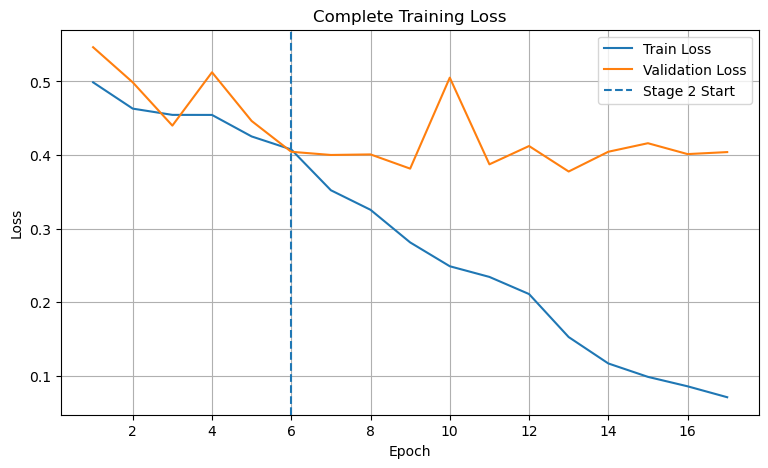

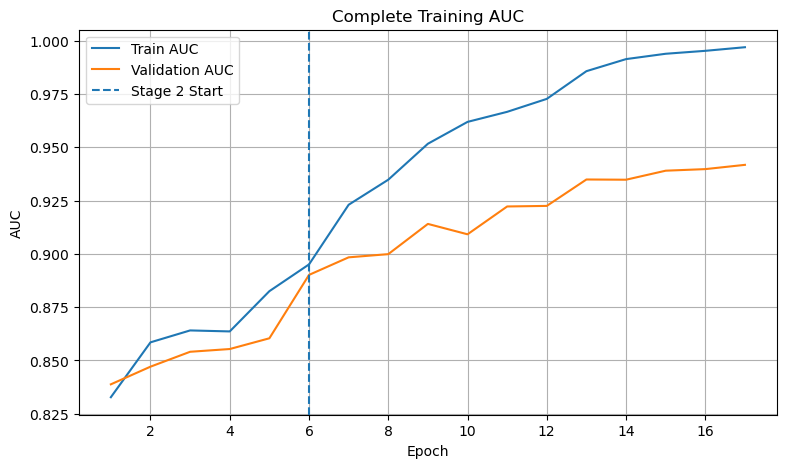

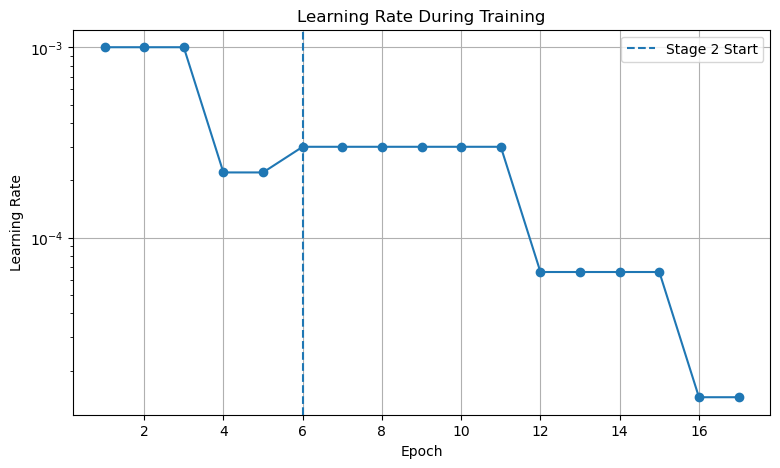

In [83]:
# ==========================================
# Point 21: Combined Training History
# ==========================================

import matplotlib.pyplot as plt


# ------------------------------------------
# Combine Stage 1 and Stage 2 histories
# ------------------------------------------

combined_train_loss = (
    history["train_loss"] +
    history_finetune["train_loss"]
)

combined_val_loss = (
    history["val_loss"] +
    history_finetune["val_loss"]
)

combined_train_auc = (
    history["train_auc"] +
    history_finetune["train_auc"]
)

combined_val_auc = (
    history["val_auc"] +
    history_finetune["val_auc"]
)

combined_lr = (
    history["learning_rate"] +
    history_finetune["learning_rate"]
)


epochs = range(
    1,
    len(combined_train_loss) + 1
)


# ==========================================
# Combined Loss
# ==========================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    combined_train_loss,
    label="Train Loss"
)

plt.plot(
    epochs,
    combined_val_loss,
    label="Validation Loss"
)

# Mark the beginning of Stage 2
stage2_start = len(history["train_loss"]) + 1

plt.axvline(
    stage2_start,
    linestyle="--",
    label="Stage 2 Start"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Complete Training Loss")

plt.legend()
plt.grid(True)

plt.show()


# ==========================================
# Combined AUC
# ==========================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    combined_train_auc,
    label="Train AUC"
)

plt.plot(
    epochs,
    combined_val_auc,
    label="Validation AUC"
)

plt.axvline(
    stage2_start,
    linestyle="--",
    label="Stage 2 Start"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Complete Training AUC")

plt.legend()
plt.grid(True)

plt.show()


# ==========================================
# Combined Learning Rate
# ==========================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    combined_lr,
    marker="o"
)

plt.axvline(
    stage2_start,
    linestyle="--",
    label="Stage 2 Start"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate During Training")

plt.yscale("log")

plt.legend()
plt.grid(True)

plt.show()

Testing: 100%|██████████| 60/60 [01:08<00:00,  1.14s/it]



FINAL TEST RESULTS
Accuracy:     0.8421
ROC-AUC:      0.9153
Precision:    0.7575
Recall:       0.7766
Specificity:  0.8750
F1 Score:     0.7669

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.8863    0.8750    0.8806      2529
   Malignant     0.7575    0.7766    0.7669      1271

    accuracy                         0.8421      3800
   macro avg     0.8219    0.8258    0.8238      3800
weighted avg     0.8432    0.8421    0.8426      3800



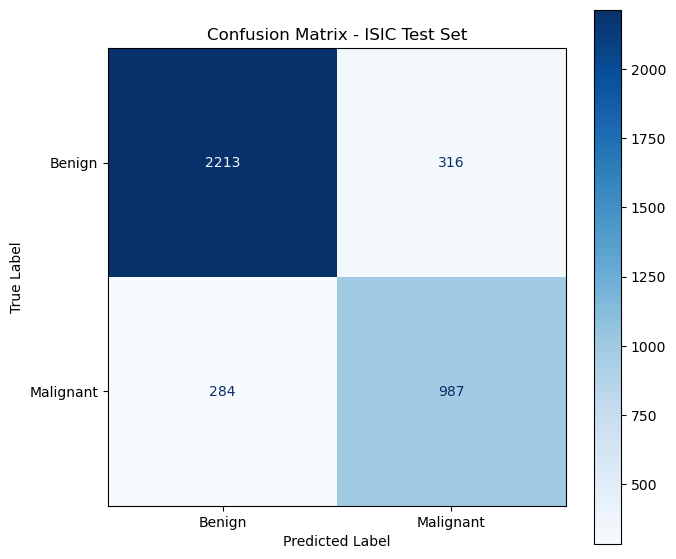


CONFUSION MATRIX (%)

Benign → Benign:       87.50%
Benign → Malignant:    12.50%
Malignant → Benign:    22.34%
Malignant → Malignant: 77.66%


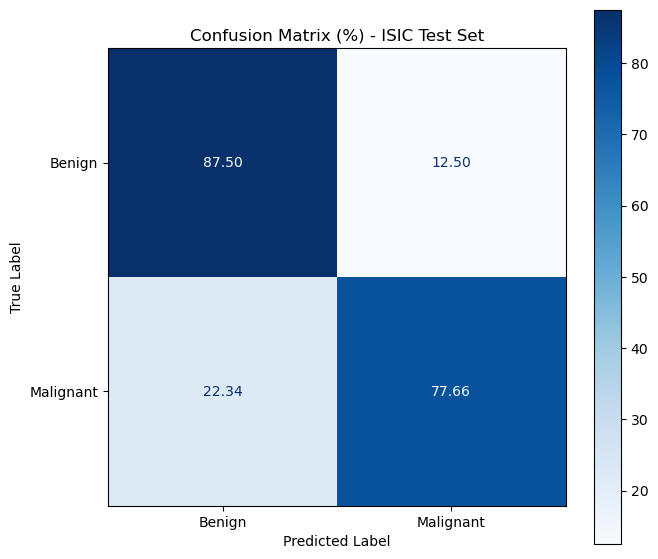

In [84]:
# ==========================================
# Point 22: Final Test Evaluation
# + Detailed Confusion Matrix
# ==========================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# ==========================================
# Evaluation mode
# ==========================================

model.eval()

all_labels = []
all_probabilities = []


# ==========================================
# Test loop
# ==========================================

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        # Move images and labels to GPU
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Channels-last format
        images = images.contiguous(
            memory_format=torch.channels_last
        )

        # Forward pass
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):

            outputs = model(
                images
            ).squeeze(1)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(
            outputs
        )

        # Store labels and probabilities
        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


# ==========================================
# Convert to NumPy
# ==========================================

all_labels = np.array(
    all_labels
)

all_probabilities = np.array(
    all_probabilities
)


# ==========================================
# Convert probabilities to predictions
# ==========================================

all_predictions = (
    all_probabilities >= 0.5
).astype(int)


# ==========================================
# Class names
# ==========================================

class_names = [
    "Benign",
    "Malignant"
]


# ==========================================
# Calculate metrics
# ==========================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)


# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ==========================================
# Specificity
# ==========================================

specificity = tn / (
    tn + fp
)


# ==========================================
# Print overall metrics
# ==========================================

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Accuracy:     {accuracy:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"F1 Score:     {f1:.4f}")

# ==========================================
# Classification Report
# ==========================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ==========================================
# Sklearn Confusion Matrix Display
# ==========================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title(
    "Confusion Matrix - ISIC Test Set"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

plt.tight_layout()

plt.show()


# ==========================================
# Confusion Matrix as Percentages
# ==========================================

cm_percent = (
    cm.astype(float) /
    cm.sum(axis=1, keepdims=True)
) * 100


print("\n" + "=" * 60)
print("CONFUSION MATRIX (%)")
print("=" * 60)

print(
    f"\nBenign → Benign:       "
    f"{cm_percent[0, 0]:.2f}%"
)

print(
    f"Benign → Malignant:    "
    f"{cm_percent[0, 1]:.2f}%"
)

print(
    f"Malignant → Benign:    "
    f"{cm_percent[1, 0]:.2f}%"
)

print(
    f"Malignant → Malignant: "
    f"{cm_percent[1, 1]:.2f}%"
)


# ==========================================
# Percentage Confusion Matrix Plot
# ==========================================

disp_percent = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp_percent.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=True
)

ax.set_title(
    "Confusion Matrix (%) - ISIC Test Set"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

plt.tight_layout()

plt.show()